In [1]:
# ==============================================================
# Distribuição isotrópica das FRBs – 2pACF com TreeCorr
# ==============================================================

# Este script implementa:
# Geração de catálogos isotrópicos na esfera celeste
# Construção de um benchmark isotrópico (Monte Carlo)
# Testes de sanidade
# Plot Mollweid de uma realização/catálogo isotrópico
# Cálculo da função de correlação angular (2pACF) usando o estimador de Landy–Szalay via TreeCorr
# Comparação com um catálogo anisotrópico (dipolo artificial)

In [2]:
# ==============================================================
# Bibliotecas
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import time
from scipy.stats import kstest
import treecorr

In [3]:
# ==============================================================
# Configuração da simulação
# ==============================================================

N_frb = 5000

In [4]:
# ==============================================================
# Geradores dos catálogos randômicos sob hiótese de isotropia
# ==============================================================

# Relização/catálogo único(a)
def generate_isotropic_catalog(n_sources, seed=None):
    """
    Gera um catálogo randômico isotrópico (H0) na esfera celeste.

    RA  = 360 * U(0,1)
    DEC = arcsin(2 * U(0,1) - 1)
    """

    rng = np.random.default_rng(seed)

    ra = 360.0 * rng.random(n_sources)
    u  = rng.random(n_sources)
    dec = np.degrees(np.arcsin(2.0*u - 1.0))

    return pd.DataFrame({"RA": ra, "DEC": dec})


# Conjunto de realizações (Benchmark)
def generate_isotropic_ensemble(n_sources, n_realizations, seed=None):
    """
    Gera um ensemble isotrópico (benchmark sob H0).
    """

    rng = np.random.default_rng(seed)
    catalogs = []

    for _ in range(n_realizations):
        catalogs.append(
            generate_isotropic_catalog(
                n_sources=n_sources,
                seed=rng.integers(0, 1e9)
            )
        )

    return catalogs


# Catálogo com um dipolo com amplitude A
def generate_dipole_catalog(n_sources, A=0.05, direction=(0, 0), seed=None):
    """
    Gera um catálogo com anisotropia dipolar controlada:

        P(n) ∝ 1 + A (n · d)
    """

    rng = np.random.default_rng(seed)

    ra_d, dec_d = np.deg2rad(direction)
    d = np.array([
        np.cos(dec_d) * np.cos(ra_d),
        np.cos(dec_d) * np.sin(ra_d),
        np.sin(dec_d)
    ])

    ra, dec = [], []

    while len(ra) < n_sources:
        ra_try = 360.0 * rng.random()
        u = 2.0 * rng.random() - 1.0
        dec_try = np.degrees(np.arcsin(u))

        n = np.array([
            np.cos(np.deg2rad(dec_try)) * np.cos(np.deg2rad(ra_try)),
            np.cos(np.deg2rad(dec_try)) * np.sin(np.deg2rad(ra_try)),
            np.sin(np.deg2rad(dec_try))
        ])

        p = 1.0 + A * np.dot(n, d)
        if rng.random() < p / (1 + abs(A)):
            ra.append(ra_try)
            dec.append(dec_try)

    return pd.DataFrame({"RA": ra, "DEC": dec})

In [5]:
# ==========================
# catálogos
# ==========================

# Catálogo isotrópico único
iso_catalog = generate_isotropic_catalog(n_sources=N_frb, seed=42)

# Conjunto isotrópico (benchmark)
iso_ensemble = generate_isotropic_ensemble(n_sources=N_frb, n_realizations=1000, seed=123)

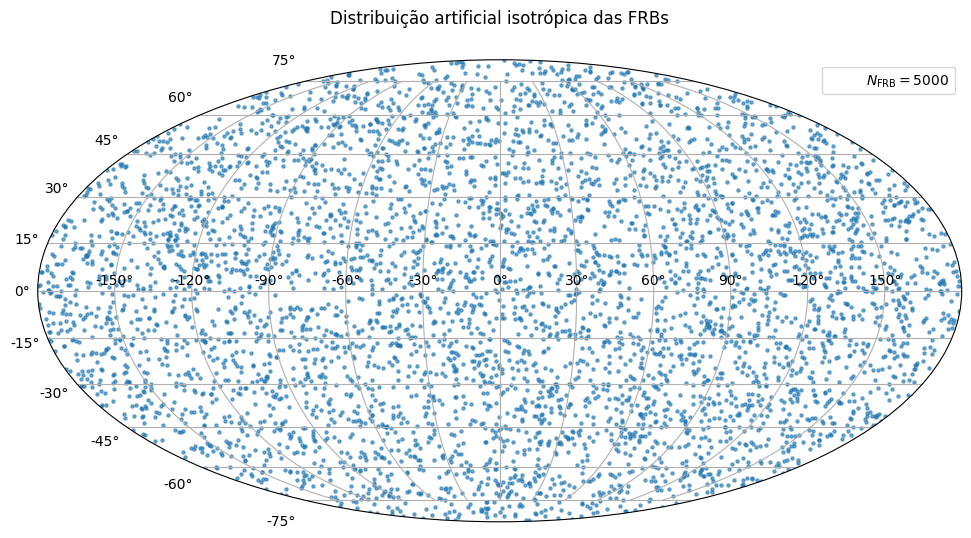

In [6]:
# ==========================
# Mollweide
# ==========================

def plot_mollweide(catalog, title="Distribuição isotrópica"):
    """
    Plota a distribuição celeste em projeção Mollweide.
    
    
    Parâmetros
    ------------------------------
    catalog : colunas 'RA' e 'DEC' em graus (pandas.DataFrame)
    title : Título do gráfico (str)
    """
        
    # Converter para radianos
    ra = np.radians(catalog["RA"].values)
    dec = np.radians(catalog["DEC"].values)

    # Converter RA de [0, 2pi] para [-pi, pi]
    ra = ra - np.pi

    # Inverter RA para convenção astronômica
    ra = - ra

    # Gerar a figura
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection="mollweide")

    ax.scatter(ra, dec, s=5, alpha=0.6)
    
    ax.plot([], [], ' ', label=f"$N_{{\\rm FRB}} = {len(catalog)}$")
    ax.legend(loc="upper right", frameon=True)
    
    ax.set_title(title, pad=26)
    ax.grid(True)

    plt.show()

plot_mollweide(iso_catalog, "Distribuição artificial isotrópica das FRBs")

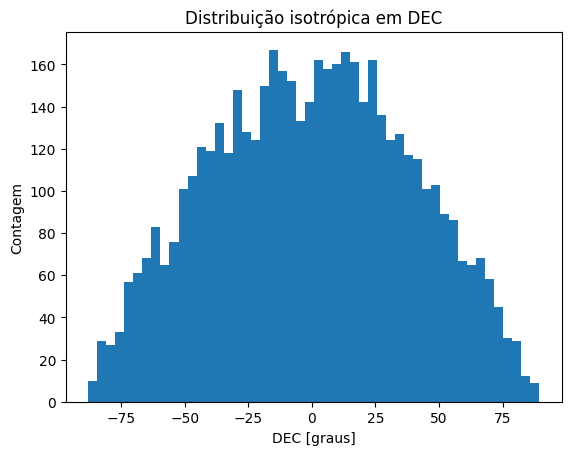

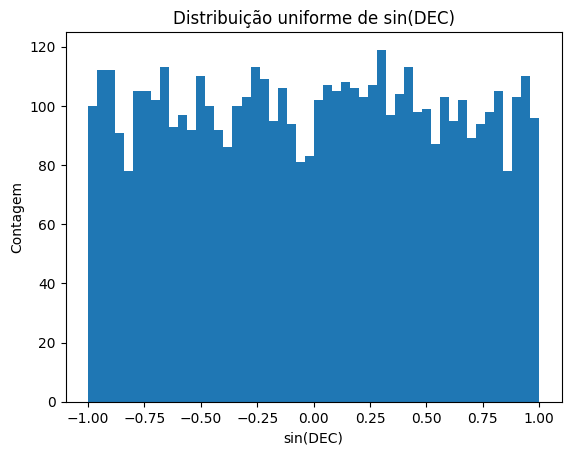

In [7]:
# ==============================================================
# Testes de sanidade geométricos
# ==============================================================

def check_dec_distribution(catalog):
    """
    Distribuição de DEC (não uniforme).
    """

    plt.figure()
    plt.hist(catalog["DEC"], bins=50)
    plt.xlabel("DEC [graus]")
    plt.ylabel("Contagem")
    plt.title("Distribuição isotrópica em DEC")
    plt.show()
    
def check_sin_dec_distribution(catalog):
    """
    Distribuição de sen(DEC) (uniforme).
    """

    sin_dec = np.sin(np.radians(catalog["DEC"]))

    plt.figure()
    plt.hist(sin_dec, bins=50)
    plt.xlabel("sin(DEC)")
    plt.ylabel("Contagem")
    plt.title("Distribuição uniforme de sin(DEC)")
    plt.show()

# Testes de sanidade
check_dec_distribution(iso_catalog)
check_sin_dec_distribution(iso_catalog)

In [8]:
# ==============================================================
# Estatísticas e Estimadores de anisotropia
# ==============================================================

In [9]:
# Teste KS em sen(DEC)
def ks_dec_test(catalog):
    """
    Teste KS da uniformidade de sen(DEC).

    Este teste compara diretamente com a distribuição
    teórica uniforme (não usa benchmark MC).
    """

    u = np.sin(np.deg2rad(catalog["DEC"].values))
    stat, pvalue = kstest(u, 'uniform', args=(-1, 2))
    return stat, pvalue

def ks_dec_pvalue_calibration(iso_ensemble):
    pvals = []
    for cat in tqdm(iso_ensemble, desc="Calibração KS(DEC)", unit="catálogo"):
        _, p = ks_dec_test(cat)
        pvals.append(p)
    return np.array(pvals)

# resultado
pvals_ks_dec = ks_dec_pvalue_calibration(iso_ensemble)
ks_stat, ks_p = kstest(pvals_ks_dec, 'uniform')

print("\n===== KS dos p-values (sin DEC) =====")
print(f"D = {ks_stat:.4e}")
print(f"p = {ks_p:.4f}")
print("====================================")

Calibração KS(DEC):   0%|          | 0/1000 [00:00<?, ?catálogo/s]


===== KS dos p-values (sin DEC) =====
D = 2.7133e-02
p = 0.4454


In [10]:
# Vetor dipolar (Rayleigh)
def dipole_vector(catalog):
    """
    Calcula o vetor médio direcional:

    R = (1/N) Σ n_i
    Para isotropia: |R| ~ O(N^{-1/2})
    """

    ra = np.deg2rad(catalog["RA"].values)
    dec = np.deg2rad(catalog["DEC"].values)

    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    R = np.array([x.mean(), y.mean(), z.mean()])
    return R, np.linalg.norm(R)


# p-value empírico do dipolo via benchmark
def dipole_pvalue(catalog, iso_ensemble):
    """
    Calcula o p-value empírico do dipolo comparando
    o valor observado com o ensemble isotrópico.
    """

    _, R_obs = dipole_vector(catalog)
    R_mc = np.array([dipole_vector(cat)[1] for cat in iso_ensemble])
    p = np.mean(R_mc >= R_obs)

    return R_obs, p, R_mc


In [11]:
# ==============================================================
# Validação estatística sob H0
# ==============================================================


# Calibração dos p-values
def pvalue_calibration(iso_ensemble):
    """
    Trata cada realização isotrópica como 'observada'
    e constrói a distribuição dos p-values.

    Sob H0: p ~ Uniforme(0,1)
    """

    pvals = []
    n = len(iso_ensemble)

    start_time = time.time()

    for i, cat in enumerate(
        tqdm(
            iso_ensemble,
            desc="Calibração H₀: p-values",
            unit="catálogo"
        )
    ):
        # Ensemble de referência (exclui o próprio catálogo)
        ref = iso_ensemble[:i] + iso_ensemble[i+1:]

        _, p, _ = dipole_pvalue(cat, ref)
        pvals.append(p)

    elapsed = time.time() - start_time
    print(f"\nTempo total: {elapsed/60:.2f} minutos")

    return np.array(pvals)

pvals = pvalue_calibration(iso_ensemble)

Calibração H₀: p-values:   0%|          | 0/1000 [00:00<?, ?catálogo/s]


Tempo total: 3.87 minutos


In [12]:
# ==============================================================
# Análise da calibração dos p-values
# ==============================================================

ks_stat, ks_p = kstest(pvals, 'uniform')

print("\n===== Interpretação de p =====")
print("p>0.95: calibração excelente")
print("p>0.05: calibração adequada")
print("p<0.05: problema na calibração")
print("==============================================\n")

print("\n===== Interpretação de D =====")
print("D = sup_x[Fn(x) - F(x)]")
print("sup_x: o maior valor possível que uma função atinge ao variar x")
print("Fn(x): CDF empírica dos p-values)")
print("Fn(x): CDF da distribuição uniforme")
print("D pequeno (~0): distribuições quase idênticas; D grande: há desvio sistemático")
print("==============================================\n")

print("\n===== Resultado do teste KS =====")
print(f"KS p-values vs uniforme: D = {ks_stat:.4e}, p = {ks_p:.4f}")
print("==============================================\n")

print("\n===== Diagnóstico da calibração =====")
if ks_p > 0.95:
    print("Resultado     : CALIBRAÇÃO EXCELENTE")
    print("Interpretação : A distribuição dos p-values é praticamente indistinguível da uniforme.")
    print("Conclusão     : O método está estatisticamente muito bem calibrado sob H₀ (isotropia).")

elif ks_p > 0.05:
    print("Resultado     : CALIBRAÇÃO ADEQUADA")
    print("Interpretação : A distribuição dos p-values é consistente com a uniforme.")
    print("Conclusão     : Não há evidência de viés estatístico relevante sob H₀.")

else:
    print("Resultado     : PROBLEMA DE CALIBRAÇÃO")
    print("Interpretação : A distribuição dos p-values difere significativamente da uniforme.")
    print("Conclusão     : O método pode estar gerando falsos positivos ou vieses sistemáticos.")
print("==============================================\n")

print("H₀ significa hipótese nula (isotropia)")


===== Interpretação de p =====
p>0.95: calibração excelente
p>0.05: calibração adequada
p<0.05: problema na calibração


===== Interpretação de D =====
D = sup_x[Fn(x) - F(x)]
sup_x: o maior valor possível que uma função atinge ao variar x
Fn(x): CDF empírica dos p-values)
Fn(x): CDF da distribuição uniforme
D pequeno (~0): distribuições quase idênticas; D grande: há desvio sistemático


===== Resultado do teste KS =====
KS p-values vs uniforme: D = 1.0000e-03, p = 1.0000


===== Diagnóstico da calibração =====
Resultado     : CALIBRAÇÃO EXCELENTE
Interpretação : A distribuição dos p-values é praticamente indistinguível da uniforme.
Conclusão     : O método está estatisticamente muito bem calibrado sob H₀ (isotropia).

H₀ significa hipótese nula (isotropia)


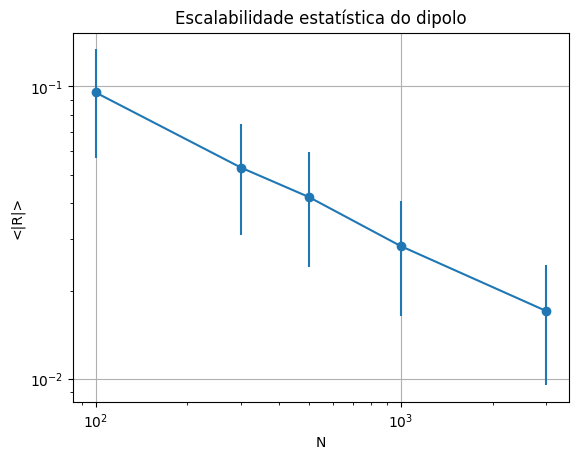

In [13]:
# ==============================================================
# Escalabilidade com o número de fontes
# ==============================================================

def scaling_with_N(N_values, n_realizations=500):
    """
    Estuda como <|R|> escala com N.
    Esperado: <|R|> ∝ N^{-1/2}
    """

    means, stds = [], []

    for N in N_values:
        ensemble = generate_isotropic_ensemble(N, n_realizations)
        Rvals = [dipole_vector(cat)[1] for cat in ensemble]
        means.append(np.mean(Rvals))
        stds.append(np.std(Rvals))

    return np.array(means), np.array(stds)


N_vals = [100, 300, 500, 1000, 3000]
mean_R, std_R = scaling_with_N(N_vals)


plt.figure()
plt.errorbar(N_vals, mean_R, yerr=std_R, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('<|R|>')
plt.title('Escalabilidade estatística do dipolo')
plt.grid()
plt.show()

Teste de potência: amplitudes A:   0%|          | 0/4 [00:00<?, ?A/s]

Realizações (A = 0.010):   0%|          | 0/200 [00:00<?, ?sim/s]

Realizações (A = 0.020):   0%|          | 0/200 [00:00<?, ?sim/s]

Realizações (A = 0.050):   0%|          | 0/200 [00:00<?, ?sim/s]

Realizações (A = 0.100):   0%|          | 0/200 [00:00<?, ?sim/s]


Tempo total do teste de potência: 3.56 minutos


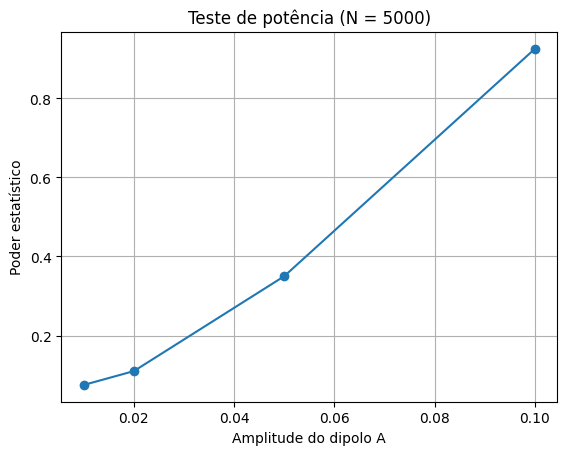

In [14]:
# ==============================================================
# Teste de potência (Anisotropia controlada)
# ==============================================================

def dipole_power_test(N, A_values, n_realizations=200):
    """
    Mede a taxa de detecção do dipolo para diferentes
    amplitudes artificiais A.
    """

    power = []

    # Benchmark isotrópico fixo (H0)
    iso_ensemble = generate_isotropic_ensemble(N, 1000, seed=1)

    start_total = time.time()

    for A in tqdm(
        A_values,
        desc="Teste de potência: amplitudes A",
        unit="A"
    ):
        detections = 0

        for _ in tqdm(
            range(n_realizations),
            desc=f"Realizações (A = {A:.3f})",
            unit="sim",
            leave=False
        ):
            cat = generate_dipole_catalog(N, A=A)
            _, p, _ = dipole_pvalue(cat, iso_ensemble)

            if p < 0.05:
                detections += 1

        power.append(detections / n_realizations)

    elapsed = time.time() - start_total
    print(f"\nTempo total do teste de potência: {elapsed/60:.2f} minutos")

    return power


A_vals = [0.01, 0.02, 0.05, 0.1]
power = dipole_power_test(N_frb, A_vals)

plt.figure()
plt.plot(A_vals, power, marker='o')
plt.xlabel('Amplitude do dipolo A')
plt.ylabel('Poder estatístico')
plt.title(f'Teste de potência (N = {N_frb})')
plt.grid()
plt.show()

In [15]:
# ==============================================================
# Interface com o Treecorr
# ==============================================================

def df_to_treecorr_catalog(df):
    """
    Converte DataFrame (RA, DEC em graus)
    em treecorr.Catalog.
    """

    return treecorr.Catalog(
        ra=df["RA"].values,
        dec=df["DEC"].values,
        ra_units="deg",
        dec_units="deg"
    )

In [16]:
# ==============================================================
# 2pACF – Landy–Szalay (TreeCorr 5.x)
# ==============================================================

def two_point_acf_treecorr(cat_df, rand_df, min_sep=0.1, max_sep=180.0, nbins=18):
    """
    Calcula a função de correlação angular 2pACF:

        w(θ) = (DD - 2DR + RR) / RR
    """

    cat = df_to_treecorr_catalog(cat_df)
    rnd = df_to_treecorr_catalog(rand_df)

    nn = treecorr.NNCorrelation(
        min_sep=min_sep,
        max_sep=max_sep,
        nbins=nbins,
        sep_units="deg"
    )

    rr = nn.copy()
    nr = nn.copy()

    nn.process(cat)          # DD
    rr.process(rnd)          # RR
    nr.process(cat, rnd)     # DR

    # TreeCorr >= 5.x: argumentos keyword-only
    nn.calculateXi(rr=rr, dr=nr)

    xi    = nn.xi
    varxi = nn.varxi

    theta = np.exp(nn.meanlogr)  # centro dos bins (graus)

    return theta, xi, varxi

In [17]:
# ==============================================================
# [4] BENCHMARK ISOTRÓPICO DA 2pACF
# ==============================================================

def benchmark_2pacf_treecorr(iso_ensemble):
    """
    Constrói o benchmark Monte Carlo da 2pACF sob H0.
    """

    w_all = []

    for cat in tqdm(iso_ensemble, desc="Benchmark isotrópico – 2pACF"):
        rand = generate_isotropic_catalog(len(cat))
        theta, w, _ = two_point_acf_treecorr(cat, rand)
        w_all.append(w)

    w_all = np.array(w_all)

    return theta, w_all.mean(axis=0), w_all.std(axis=0), w_all

In [18]:
# ==============================================================
# [5] EXECUÇÃO
# ==============================================================


# Benchmark isotrópico
iso_ensemble = generate_isotropic_ensemble(
    n_sources=N_frb,
    n_realizations=300,
    seed=123
)

theta, w_mean, w_std, w_all = benchmark_2pacf_treecorr(iso_ensemble)

Benchmark isotrópico – 2pACF:   0%|          | 0/300 [00:00<?, ?it/s]

In [ ]:
# ==============================================================
# CATÁLOGO ISOTRÓIPICO
# ==============================================================

cat_iso_obs = generate_isotropic_catalog(
    n_sources=N_frb,
    seed=999
)

rand_ref = generate_isotropic_catalog(N_frb, seed=888)

theta_obs, w_obs, _ = two_point_acf_treecorr(cat_iso_obs, rand_ref)

# ==============================================================
# [6] CATÁLOGO ANISOTRÓPICO
# ==============================================================

cat_dipole = generate_dipole_catalog(n_sources=N_frb, A=0.05, direction=(0, 0), seed=999)

rand_ref = generate_isotropic_catalog(N_frb, seed=888)

theta_obs, w_obs, _ = two_point_acf_treecorr(cat_dipole, rand_ref)

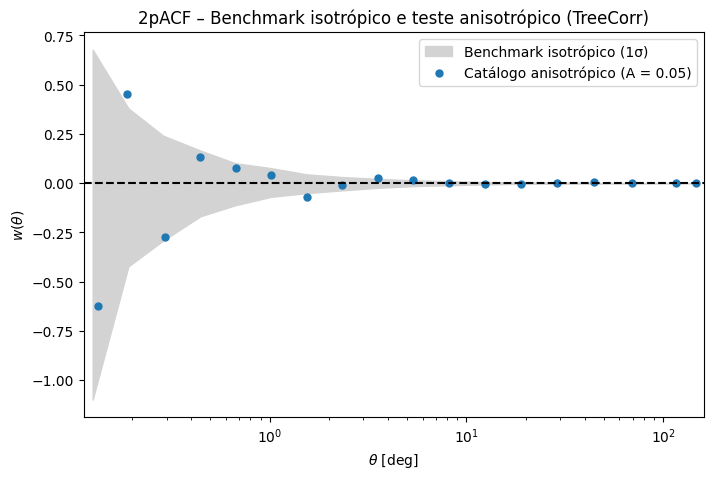

In [33]:
# ==============================================================
# [7] PLOT
# ==============================================================

plt.figure(figsize=(8,5))

plt.fill_between(
    theta,
    w_mean - w_std,
    w_mean + w_std,
    color="lightgray",
    label="Benchmark isotrópico (1σ)"
)

plt.plot(
    theta_obs,
    w_obs,
    "o",
    ms=5,
    label="Catálogo anisotrópico (A = 0.05)"
)

plt.axhline(0, color="k", ls="--")
plt.xscale("log")
plt.xlim(theta.min()*0.9, theta.max()*1.1)

plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$w(\theta)$")
plt.title("2pACF – Benchmark isotrópico e teste anisotrópico (TreeCorr)")
plt.legend()
plt.show()

In [34]:
# ==============================================================
# ABSOLUTE SUM TEST
# ==============================================================

# Bins largos em ângulo (0–20, 20–40, ..., 160–180)
theta_bins = np.arange(0.0, 181.0, 20.0)
theta_centers = 0.5 * (theta_bins[:-1] + theta_bins[1:])


def absolute_sum(theta, w, theta_bins):
    """
    Calcula a Absolute Sum da 2pACF em bins largos de ângulo.
    """

    abs_sum = []

    for i in range(len(theta_bins) - 1):
        mask = (theta >= theta_bins[i]) & (theta < theta_bins[i+1])
        S = np.sum(np.abs(w[mask]))
        abs_sum.append(S)

    return np.array(abs_sum)


# Absolute sum do benchmark (todas as realizações)
abs_bench_all = np.array([
    absolute_sum(theta, w_i, theta_bins) for w_i in w_all
])

abs_bench_mean = abs_bench_all.mean(axis=0)
abs_bench_std  = abs_bench_all.std(axis=0)

# Absolute Sum do catálogo observado
abs_obs = absolute_sum(theta_obs, w_obs, theta_bins)

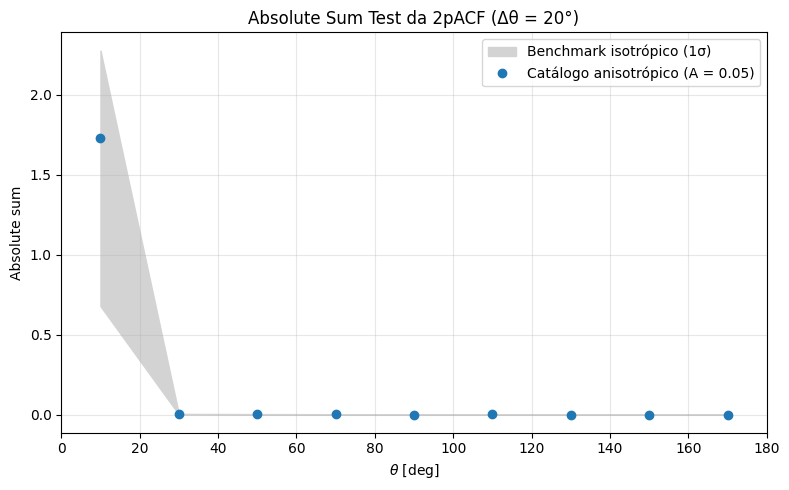

In [35]:
plt.figure(figsize=(8,5))

# Benchmark isotrópico (região sombreada)
plt.fill_between(
    theta_centers,
    abs_bench_mean - abs_bench_std,
    abs_bench_mean + abs_bench_std,
    color="lightgray",
    label="Benchmark isotrópico (1σ)"
)

# Catálogo observado (sem barras de erro)
plt.plot(
    theta_centers,
    abs_obs,
    "o",
    color="tab:blue",
    label="Catálogo anisotrópico (A = 0.05)"
)

plt.xlabel(r"$\theta$ [deg]")
plt.ylabel("Absolute sum")
plt.xlim(0, 180)
plt.title("Absolute Sum Test da 2pACF (Δθ = 20°)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()